<a href="https://colab.research.google.com/github/Andrew-Ayegh/Dual-Stream-Prostate-Cancer-Detection/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# import os
# os.makedirs('/content/drive/MyDrive/PICAI/images', exist_ok=True)
# os.makedirs('/content/drive/MyDrive/PICAI/labels', exist_ok=True)

In [4]:
# !wget -P /content/drive/MyDrive/PICAI/images \
# https://zenodo.org/records/6624726/files/picai_public_images_fold0.zip

In [5]:
# import zipfile
# import os

# zip_path = '/content/drive/MyDrive/PICAI/images/picai_public_images_fold0.zip'
# extract_path = '/content/drive/MyDrive/PICAI/images/'

# print("Unzipping fold 0...")
# with zipfile.ZipFile(zip_path, 'r') as zf:
#     zf.extractall(extract_path)

# # Delete zip to save space
# os.remove(zip_path)
# print("Fold 0 done. Zip deleted.")

In [6]:
# !wget -P /content/drive/MyDrive/PICAI/images \
# https://zenodo.org/records/6624726/files/picai_public_images_fold1.zip

In [7]:
# import zipfile
# import os

# zip_path = '/content/drive/MyDrive/PICAI/images/picai_public_images_fold1.zip'
# extract_path = '/content/drive/MyDrive/PICAI/images/'

# print("Unzipping fold 1...")
# with zipfile.ZipFile(zip_path, 'r') as zf:
#     zf.extractall(extract_path)

# # Delete zip to save space
# os.remove(zip_path)
# print("Fold 0 done. Zip deleted.")

In [8]:
# import glob

# files = glob.glob('/content/drive/MyDrive/PICAI/images/**/*.mha', recursive=True)
# print(f"Total MHA files found: {len(files)}")

# # Show first 5 files so you can see the structure
# for f in files[:5]:
#     print(f)

In [9]:
# !wget -P /content/drive/MyDrive/PICAI/images \
# https://zenodo.org/records/6624726/files/picai_public_images_fold3.zip

In [10]:
# import zipfile
# import os

# zip_path = '/content/drive/MyDrive/PICAI/images/picai_public_images_fold3.zip'
# extract_path = '/content/drive/MyDrive/PICAI/images/'

# print("Unzipping fold 3...")
# with zipfile.ZipFile(zip_path, 'r') as zf:
#     zf.extractall(extract_path)

# # Delete zip to save space
# os.remove(zip_path)
# print("Fold 3 done. Zip deleted.")

In [11]:
# import glob

# files = glob.glob('/content/drive/MyDrive/PICAI/images/**/*.mha', recursive=True)
# print(f"Total MHA files found: {len(files)}")

# # Count unique patients
# patients = set([f.split('/')[-2] for f in files])
# print(f"Total unique patient folders: {len(patients)}")

# # Show first 5 files
# for f in files[:5]:
#     print(f)


In [12]:
# !wget -P /content/drive/MyDrive/PICAI/images \
# https://zenodo.org/records/6624726/files/picai_public_images_fold2.zip

In [13]:
# import zipfile
# import os

# zip_path = '/content/drive/MyDrive/PICAI/images/picai_public_images_fold2.zip'
# extract_path = '/content/drive/MyDrive/PICAI/images/'

# print("Unzipping fold 2...")
# with zipfile.ZipFile(zip_path, 'r') as zf:
#     zf.extractall(extract_path)

# # Delete zip to save space
# os.remove(zip_path)
# print("Fold 2 done. Zip deleted.")

In [14]:
# !wget -P /content/drive/MyDrive/PICAI/images \
# https://zenodo.org/records/6624726/files/picai_public_images_fold4.zip

In [15]:
# import zipfile
# import os

# zip_path = '/content/drive/MyDrive/PICAI/images/picai_public_images_fold4.zip'
# extract_path = '/content/drive/MyDrive/PICAI/images/'

# print("Unzipping fold 4...")
# with zipfile.ZipFile(zip_path, 'r') as zf:
#     zf.extractall(extract_path)

# # Delete zip to save space
# os.remove(zip_path)
# print("Fold 4 done. Zip deleted.")

In [16]:
# !wget -P /content/drive/MyDrive/PICAI/labels \
# https://github.com/DIAGNijmegen/picai_labels/archive/refs/heads/main.zip

In [17]:
# with zipfile.ZipFile('/content/drive/MyDrive/PICAI/labels/main.zip', 'r') as zf:
#     zf.extractall('/content/drive/MyDrive/PICAI/labels/')
# os.remove('/content/drive/MyDrive/PICAI/labels/main.zip')
# print("Labels downloaded and extracted")

In [18]:
# files = glob.glob('/content/drive/MyDrive/PICAI/images/**/*.mha', recursive=True)
# print(f"Total MHA files: {len(files)}")
# # Should be approximately 7500 files

In [19]:
# import glob

# label_files = glob.glob('/content/drive/MyDrive/PICAI/labels/**/*', recursive=True)
# print(f"Total label files: {len(label_files)}")

# # Show structure
# for f in label_files[:5]:
#     print(f)

In [20]:
# ---------------IMPORT AND INSTALL LIBRARIES -------------------------#
!pip install picai-baseline SimpleITK captum scikit-learn seaborn -q
!pip install picai_prep -q



#---------- Mount Google Drive-----------#
from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import SimpleITK as sitk
import torch
import torchvision
from torch import nn
import sklearn
import json
from pprint import pprint
import SimpleITK as sitk
import numpy as np
import picai_prep
import picai_prep.preprocessing as pp
from picai_prep.preprocessing import PreprocessingSettings, Sample
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torchvision.transforms.functional as TF
import random
from PIL import Image
from collections import Counter


# --------Verify if GPU is being used------------#
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print("Setup complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 907.8/907.8 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 110.2 MB/s eta 0:00:00
Mounted at /content/drive
If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_prep

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Setup complete


In [21]:
# --------------------Extracting names adc and t2w path names for every scan -------------------#
IMAGE_FOLDER = '/content/drive/MyDrive/PICAI/images'
pairs = []
incomplete_scan = []
x=0
for root, dirs, files in os.walk(IMAGE_FOLDER):
    #----------SKIP THE BASE DIRECTORY
    if root == IMAGE_FOLDER:
        continue
    t2w_file = None
    adc_file = None
    # --------- Check files in the current patient folder
    for file in files:
        if file.endswith('_t2w.mha'):
            t2w_file = os.path.join(root, file)
        elif file.endswith('_adc.mha'):
            adc_file = os.path.join(root, file)

    if t2w_file and adc_file:
        patient_id = os.path.basename(root)
        pairs.append({
            'patient_id': patient_id,
            't2w': t2w_file,
            'adc': adc_file
        })
    else:
        incomplete_scan.append(root)

with open('/content/drive/MyDrive/PICAI/pairs.json', 'w') as f:
    json.dump(pairs, f, indent=2)


print(f"Total paired patients found: {len(pairs)}")
print(f"Total incomplete patient folders found: {len(incomplete_scan)}")

# if incomplete_scan:
#     print("\nFirst 3 incomplete folders:")
#     for folder in incomplete_scan[:3]:
#         print(folder)
#         print(len(folder))



Total paired patients found: 1476
Total incomplete patient folders found: 0


In [22]:
# ------------Read Stored json file with file path pairs ---------------#
with open('/content/drive/MyDrive/PICAI/pairs.json', 'r') as f:
    image_pairs = json.load(f)

pprint(image_pairs[:2])


[{'adc': '/content/drive/MyDrive/PICAI/images/10880/10880_1000896_adc.mha',
  'patient_id': '10880',
  't2w': '/content/drive/MyDrive/PICAI/images/10880/10880_1000896_t2w.mha'},
 {'adc': '/content/drive/MyDrive/PICAI/images/10882/10882_1000898_adc.mha',
  'patient_id': '10882',
  't2w': '/content/drive/MyDrive/PICAI/images/10882/10882_1000898_t2w.mha'}]


In [23]:
# LABELS_FOLDER = '/content/drive/MyDrive/PICAI/labels/picai_labels-main/csPCa_lesion_delineations/human_expert/resampled'
# label_files = set(os.listdir(LABELS_FOLDER)) #-----list of the names of all items in a directory
# print(len(label_files))

# #-------------------- Check if any label file starts with patient_id--------------------#
# def create_target_json(image_pairs, label_files):
#   """Check the existance of files in the feature folder that matches available patient id scans to determine classification of scans"""
#   targets = []
#   for x in image_pairs:
#     has_label = any(f.startswith(x['patient_id']) for f in label_files)
#     if has_label:
#       diagnosis = 1
#     else:
#       diagnosis = 0

#     full_dataset = {
#     'patient_id': x['patient_id'],
#     't2w': x['t2w'],
#     'adc': x['adc'],
#     'diagnosis': diagnosis
#     }
#     targets.append(full_dataset)




# # -------------Create new json file with patient_id and target-----------------------#
#   with open('/content/drive/MyDrive/PICAI/dataset.json', 'w') as f:
#       json.dump(targets, f, indent=2)
#   print ("Saved to dataset.json")

# create_target_json(image_pairs, label_files)








In [24]:
marksheet_path = '/content/drive/MyDrive/PICAI/labels/picai_labels-main/clinical_information/marksheet.csv'
df = pd.read_csv(marksheet_path)
# ------------Read Stored json file with file path pairs ---------------#
with open('/content/drive/MyDrive/PICAI/pairs.json', 'r') as f:
    pairs = json.load(f)
df['patient_id_str'] = df['patient_id'].astype(str)

label_mapping = {'YES': 1, 'NO': 0}
df['diagnosis'] = df['case_csPCa'].map(label_mapping)

# Turn it into a python dictionary for fast lookup
lookup_dict = dict(zip(df['patient_id_str'], df['diagnosis']))
# Loop through previous data and create the new list of dictionaries
labeled_dataset = []
missing_labels_count = 0

for patient in pairs:
    # print(patient)
    p_id = str(patient['patient_id'])
    if p_id in lookup_dict:
        # Create a copy of the previous data and add the diagnosis label
        updated_patient = patient.copy()
        updated_patient['diagnosis'] = int(lookup_dict[p_id])
        labeled_dataset.append(updated_patient)
    else:
        missing_labels_count += 1
        print(f"Warning: No clinical label found for patient {p_id}")
print(len(labeled_dataset))

with open('/content/drive/MyDrive/PICAI/labeled_dataset.json', 'w') as f:
    json.dump(labeled_dataset, f, indent=2)


# Diagnostics
# print(f"Successfully matched and labeled: {len(labeled_dataset)} patients")
# print(f"Patients missing from clinical sheet: {missing_labels_count}")
# # print(df.columns.tolist())
# print(df.head(10))
# print(f"\nTotal rows: {len(df)}")
# print(f"\nValue counts for csPCa column:")
# print(df['case_csPCa'].value_counts())

1476


In [25]:
with open ('/content/drive/MyDrive/PICAI/labeled_dataset.json', 'r') as f:
    dataset = json.load(f)

malignant = sum(1 for data in dataset if data['diagnosis'] == 1)
benign = len(dataset) - malignant

In [26]:
# ------logged data for chapter 4----------#
total_cases = len(dataset)
benign_cases = benign
malignant_cases = malignant
print(f"Total cases: {total_cases}")
print(f"Benign cases: {benign_cases}")
print(f"Malignant cases: {malignant_cases}")

Total cases: 1476
Benign cases: 1051
Malignant cases: 425


In [27]:
# --------------Preprocessing Pipeline-----------#
def read_mha(file_path):
    image = sitk.ReadImage(file_path)

    #--------Get spacing (voxel dimensions in millimeter)
    spacing = image.GetSpacing()

    #-------Convert to numpy array
    array = sitk.GetArrayFromImage(image)

    print(f"Shape: {array.shape}")
    print(f"Spacing: {spacing}")
    print(f"Min value: {array.min():.2f}")
    print(f"Max value: {array.max():.2f}")


    return image, array

#--------Test on first T2W file
first_t2w = dataset[0]['t2w']
image, array = read_mha(first_t2w)


Shape: (19, 384, 384)
Spacing: (0.5, 0.5, 3.0000000422238333)
Min value: 0.00
Max value: 1266.00


In [28]:
# pprint(dir(picai_prep))

In [29]:

# pprint(dir(pp))

In [30]:
# help(pp.PreprocessingSettings)
# help(pp.Sample)

In [31]:
CHECKPOINT_FILE = '/content/drive/MyDrive/PICAI/checkpoint.json'

def load_checkpoint():
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            return set(json.load(f))
    return set()

def save_checkpoint(processed_ids):
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump(list(processed_ids), f, indent=2)

# Configure preprocessing settings

def preprocess_data(dataset:list):
  settings = PreprocessingSettings(
    matrix_size=(20, 256, 256),  # ----------z, y, x — 20 slices, 256x256 per slice
    spacing=(3.0, 0.5, 0.5)      # --------- z, y, x spacing in mm
    )
  count = 0
  processed_data =[]
  #---------- Read T2W and ADC as SimpleITK images
  for patient in dataset:
    t2w_image = sitk.ReadImage(patient['t2w'])
    adc_image = sitk.ReadImage(patient['adc'])

    #--------Create sample — T2W first so ADC registers to it
    sample = Sample(
    scans=[t2w_image, adc_image],
    settings=settings,
    name=patient['patient_id']
    )

    #-------Run all preprocessing in one call
    sample.preprocess()
    t2w_array_before = sitk.GetArrayFromImage(t2w_image)
    adc_array_before = sitk.GetArrayFromImage(adc_image)
    #-------- Convert to numpy arrays
    t2w_array = sitk.GetArrayFromImage(sample.scans[0])
    adc_array = sitk.GetArrayFromImage(sample.scans[1])

    processed_data.append(patient['patient_id'])


    count += 1

    if count <2:
      print(f"Patient: {patient['patient_id']}")
      print(f"T2W shape after preprocessing-{t2w_array.shape}:T2W shape before preprocessing-{t2w_array_before.shape}")
      print(f"ADC shape after preprocessing-{adc_array.shape}:ADC shape before preprocessing-{adc_array_before.shape}")
      print(f"T2W min/max: {t2w_array.min():.2f} / {t2w_array.max():.2f}")
      print(f"ADC min/max: {adc_array.min():.2f} / {adc_array.max():.2f}")
    else:
      break
  print(processed_data)
  with open('/content/drive/MyDrive/PICAI/processed_data.json', 'w') as f:
      json.dump(processed_data, f, indent=2)
  print ("Saved to processed_data.json")
preprocess_data(dataset)

Patient: 10880
T2W shape after preprocessing-(20, 256, 256):T2W shape before preprocessing-(19, 384, 384)
ADC shape after preprocessing-(20, 256, 256):ADC shape before preprocessing-(19, 128, 84)
T2W min/max: 0.00 / 932.00
ADC min/max: 0.00 / 3356.00
['10880', '10882']
Saved to processed_data.json


In [32]:
SAVE_FOLDER = '/content/drive/MyDrive/PICAI/preprocessed/'
CHECKPOINT_FILE = '/content/drive/MyDrive/PICAI/checkpoint.json'
BATCH_SIZE = 50
os.makedirs(SAVE_FOLDER, exist_ok=True)


def save_checkpoint(processed_ids):
    '''populate checkpoint with preposesed data id and create new one if none exists'''
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump(list(processed_ids), f, indent=2)

def load_checkpoint():
    '''check if checkpoint to recall last preprocessed patient exists and load it up'''
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            return set(json.load(f))
    else:
        save_checkpoint([])
    return set()

def preprocess_and_save(dataset:list):
    '''preprocess data and save .npz fiel '''
    settings = PreprocessingSettings(
        matrix_size=(20, 256, 256),
        spacing=(3.0, 0.5, 0.5)
    )

    #--------- Load checkpoint — who is already done
    processed_ids = load_checkpoint()
    print(processed_ids)
    print(f"Already processed: {len(processed_ids)} patients")

    #---------Filter out already processed patients
    remaining = [p for p in dataset if p['patient_id'] not in processed_ids]
    # print(remaining)
    print(f"Remaining to process: {len(remaining)} patients")
    count = 0
    for i, patient in enumerate(remaining):
        # count += 1
        try:
            #-------Run all preprocessing in one call
            # sample.preprocess()
            # t2w_array_before = sitk.GetArrayFromImage(t2w_image)
            # adc_array_before = sitk.GetArrayFromImage(adc_image)
            # print("pass stage 1")
            # #-------- Convert to numpy arrays
            # t2w_array = sitk.GetArrayFromImage(sample.scans[0])
            # adc_array = sitk.GetArrayFromImage(sample.scans[1])
            # print("pass stage 2")

            # 1. Read T2W and ADC
            t2w_image = sitk.ReadImage(patient['t2w'])
            adc_image = sitk.ReadImage(patient['adc'])
            # print("pass stage 1")
            # 2. Create Sample and preprocess
            #--------Create sample — T2W first so ADC registers to it
            sample = Sample(
            scans=[t2w_image, adc_image],
            settings=settings,
            name=patient['patient_id']
            )
            # print("pass stage 2")
            # 3. Convert to numpy arrays
            sample.preprocess()
            t2w_array_before = sitk.GetArrayFromImage(t2w_image)
            adc_array_before = sitk.GetArrayFromImage(adc_image)
            # print("pass stage 3")
            #-------- Convert to numpy arrays
            t2w_array = sitk.GetArrayFromImage(sample.scans[0])
            adc_array = sitk.GetArrayFromImage(sample.scans[1])
            # print("pass stage 4")
            #---------Save as .npz file
            save_path = os.path.join(SAVE_FOLDER, f"{patient['patient_id']}.npz")
            np.savez_compressed(save_path, t2w=t2w_array, adc=adc_array)
            # print("pass stage 5")
            #------------Add patient_id to processed_ids list
            processed_ids.add(patient['patient_id'])


            #-----------Save checkpoint every 50 patients
            if (i + 1) % BATCH_SIZE == 0:
                save_checkpoint(processed_ids)
                print(f"Checkpoint saved — {len(processed_ids)} patients done")


        except Exception as e:
            print(f"Error on patient {patient['patient_id']}: {e}")
            continue  # skip failed patient and continue
        # if count <5:
        #   print(f"round: {count}")
        # else:
        #   break
    # Final checkpoint save
    save_checkpoint(processed_ids)
    print(f"Complete — {len(processed_ids)} patients processed")
preprocess_and_save(dataset)

{'10210', '11310', '11257', '10843', '11337', '10729', '11102', '10458', '10356', '10366', '10136', '11022', '11269', '11329', '10891', '10998', '10957', '10378', '10223', '11168', '10183', '10820', '10288', '11408', '11231', '11138', '10652', '11386', '10354', '10474', '10444', '11229', '11149', '10204', '10896', '11046', '11131', '11050', '10972', '10198', '10150', '11373', '10437', '10402', '10766', '11067', '10176', '10502', '11374', '10015', '10197', '11183', '11116', '10696', '11207', '10307', '10532', '10967', '10520', '11289', '11281', '10542', '10966', '11291', '10394', '11432', '11132', '10985', '10324', '10206', '10544', '11425', '11056', '11249', '10948', '10005', '10463', '10583', '10968', '11226', '10790', '11039', '10092', '10528', '10887', '10135', '10623', '10049', '11182', '10625', '10610', '10977', '10126', '11153', '10031', '11199', '10518', '10255', '11445', '10012', '10077', '11148', '10831', '10318', '10468', '11166', '11349', '10325', '11087', '10562', '10578', 

In [50]:

#----------------COMPUTE ADC DATASET-WISE STATISTICS
#---------------Incremental computation becuase it chaches alot of files
# --------------Processes one patient at a time to avoid
# ---------------RAM crash. Uses two passes — first for mean, second for std.

def compute_adc_stats(samples, preprocessed_folder):
    """Compute mean and std of ADC values incrementally to avoid RAM overflow"""

    # ---Compute mean
    total_sum = 0.0
    total_count = 0

    # print("Computing ADC mean...")
    for i, patient in enumerate(samples):
        npz_path = os.path.join(preprocessed_folder, f"{patient['patient_id']}.npz")
        data = np.load(npz_path)
        adc = data['adc'].astype(np.float32)

        #----------Clip outliers
        low = np.percentile(adc, 0.5)
        high = np.percentile(adc, 99.5)
        adc = np.clip(adc, low, high)

        total_sum += adc.sum()
        total_count += adc.size

        #--------Explicitly delete from memory after each patient
        del adc, data

        if (i + 1) % 100 == 0:
            print(f"  {i + 1}/{len(samples)} patients processed")

    adc_mean = total_sum / total_count
    print(f"ADC mean: {adc_mean:.4f}")

    # --------Compute std
    total_sq_diff = 0.0

    # print("Computing ADC std...")
    for i, patient in enumerate(samples):
        npz_path = os.path.join(preprocessed_folder, f"{patient['patient_id']}.npz")
        data = np.load(npz_path)
        adc = data['adc'].astype(np.float32)

        #----------Same clipping
        low = np.percentile(adc, 0.5)
        high = np.percentile(adc, 99.5)
        adc = np.clip(adc, low, high)

        total_sq_diff += ((adc - adc_mean) ** 2).sum()

        #----------Explicitly delete from memory after each patient
        del adc, data

        if (i + 1) % 100 == 0:
            print(f"  {i + 1}/{len(samples)} patients processed")

    adc_std = np.sqrt(total_sq_diff / total_count)
    print(f"ADC std: {adc_std:.4f}")

    return float(adc_mean), float(adc_std)




Total malignant: 425
Total benign: 1051

Train: 1032 patients
  Malignant: 297
  Benign: 735

Validation: 295 patients
  Malignant: 85
  Benign: 210

Test: 149 patients
  Malignant: 43
  Benign: 106

Computing ADC statistics from training set...
Computing ADC mean...
  100/1032 patients processed
  200/1032 patients processed
  300/1032 patients processed
  400/1032 patients processed
  500/1032 patients processed


KeyboardInterrupt: 

In [ ]:

#----------------------STRATIFIED SPLIT
def stratified_split(dataset):
    """Split dataset into train/val/test maintaining class distribution"""

    malignant = [p for p in dataset if p['diagnosis'] == 1]
    benign = [p for p in dataset if p['diagnosis'] == 0]

    print(f"Total malignant: {len(malignant)}")
    print(f"Total benign: {len(benign)}")

    mal_train, mal_temp = train_test_split(malignant, test_size=0.30, random_state=42)
    mal_val, mal_test = train_test_split(mal_temp, test_size=0.333, random_state=42)

    ben_train, ben_temp = train_test_split(benign, test_size=0.30, random_state=42)
    ben_val, ben_test = train_test_split(ben_temp, test_size=0.333, random_state=42)

    train_set = mal_train + ben_train
    val_set = mal_val + ben_val
    test_set = mal_test + ben_test

    random.shuffle(train_set)
    random.shuffle(val_set)
    random.shuffle(test_set)

    print(f"\nTrain: {len(train_set)} patients")
    print(f"Malignant: {sum(1 for p in train_set if p['diagnosis']==1)}")
    print(f"Benign: {sum(1 for p in train_set if p['diagnosis']==0)}")

    print(f"\nValidation: {len(val_set)} patients")
    print(f"Malignant: {sum(1 for p in val_set if p['diagnosis']==1)}")
    print(f"Benign: {sum(1 for p in val_set if p['diagnosis']==0)}")

    print(f"\nTest: {len(test_set)} patients")
    print(f"Malignant: {sum(1 for p in test_set if p['diagnosis']==1)}")
    print(f"Benign: {sum(1 for p in test_set if p['diagnosis']==0)}")

    return train_set, val_set, test_set



In [ ]:

#-----------------------AUGMENTATION
def augment_slice(t2w_slice, adc_slice):
    """Apply random augmentation to a pair of 2D slices BUT only for training data"""

    t2w_pil = TF.to_pil_image(t2w_slice.astype(np.float32))
    adc_pil = TF.to_pil_image(adc_slice.astype(np.float32))

    if random.random() > 0.5:
        t2w_pil = TF.hflip(t2w_pil)
        adc_pil = TF.hflip(adc_pil)

    if random.random() > 0.5:
        t2w_pil = TF.vflip(t2w_pil)
        adc_pil = TF.vflip(adc_pil)

    angle = random.uniform(-15, 15)
    t2w_pil = TF.rotate(t2w_pil, angle)
    adc_pil = TF.rotate(adc_pil, angle)

    brightness_factor = random.uniform(0.9, 1.1)
    contrast_factor = random.uniform(0.9, 1.1)
    t2w_pil = TF.adjust_brightness(t2w_pil, brightness_factor)
    t2w_pil = TF.adjust_contrast(t2w_pil, contrast_factor)
    adc_pil = TF.adjust_brightness(adc_pil, brightness_factor)
    adc_pil = TF.adjust_contrast(adc_pil, contrast_factor)

    t2w_aug = np.array(t2w_pil)
    adc_aug = np.array(adc_pil)

    return t2w_aug, adc_aug



In [ ]:
#--------------------------------NORMALISATION FUNCTIONS


def normalise_t2w(slice_array):
    """instance-wise z-score normalization for T2W slices."""
    low = np.percentile(slice_array, 0.5)
    high = np.percentile(slice_array, 99.5)

    if (high - low) < 1e-3:
        return np.zeros_like(slice_array)

    clipped = np.clip(slice_array, low, high)
    mean = clipped.mean()
    std = clipped.std()

    if std < 1e-2:
        return np.zeros_like(slice_array)

    epsilon = 1e-8
    return (clipped - mean) / (std + epsilon)


def normalise_adc(slice_array, adc_mean, adc_std):
    """Dataset-wise z-score normalization for ADC slices."""
    low = np.percentile(slice_array, 0.5)
    high = np.percentile(slice_array, 99.5)

    if (high - low) < 1e-3:
        return np.zeros_like(slice_array)

    clipped = np.clip(slice_array, low, high)

    if clipped.std() < 1e-2:
        return np.zeros_like(slice_array)

    epsilon = 1e-8
    return (clipped - adc_mean) / (adc_std + epsilon)




In [ ]:
#------------------ RESIZE FUNCTION
def resize_slice(slice_array, target_size=(224, 224)):
    """Resize a 2D slice to target size using bilinear interpolation"""
    slice_min = slice_array.min()
    slice_max = slice_array.max()

    if slice_max - slice_min == 0:
        slice_norm = np.zeros_like(slice_array, dtype=np.uint8)
    else:
        slice_norm = ((slice_array - slice_min) / (slice_max - slice_min) * 255).astype(np.uint8)

    pil_image = Image.fromarray(slice_norm)
    pil_resized = pil_image.resize(target_size, Image.BILINEAR)

    return np.array(pil_resized, dtype=np.float32)



In [51]:
#---------------------- DATASET CLASS
class ProstateDataset(Dataset):
    def __init__(self, samples, preprocessed_folder, mode='train', adc_mean=None, adc_std=None):
      self.preprocessed_folder = preprocessed_folder
      self.mode = mode
      self.adc_mean = adc_mean
      self.adc_std = adc_std

      #-------skipping blank slices
      self.valid_slices = []

      print(f"Building valid slice list for {mode} set...")
      for patient in samples:
          npz_path = os.path.join(preprocessed_folder, f"{patient['patient_id']}.npz")
          data = np.load(npz_path)

          for slice_idx in range(20):
              t2w_slice = data['t2w'][slice_idx]

              # Skip blank slices (slices with fewer than 50 unique values)
              if len(np.unique(t2w_slice)) > 50:
                  self.valid_slices.append({
                      'patient_id': patient['patient_id'],
                      'slice_idx': slice_idx,
                      'diagnosis': patient['diagnosis']
                  })

          del data

      print(f"Valid slices: {len(self.valid_slices)}")

    def __len__(self):
        return len(self.valid_slices)

    def __getitem__(self, index):
        #--------Get the specific valid slice
        slice_info = self.valid_slices[index]
        patient_id = slice_info['patient_id']
        slice_idx = slice_info['slice_idx']
        label = slice_info['diagnosis']

        # --------Load npz file
        npz_path = os.path.join(self.preprocessed_folder, f"{patient_id}.npz")
        data = np.load(npz_path)

        #---------Extract slice
        t2w_slice = data['t2w'][slice_idx].astype(np.float32)
        adc_slice = data['adc'][slice_idx].astype(np.float32)

        # --------Resize slice (output data in a clean 0-255 range)
        t2w_slice = resize_slice(t2w_slice)
        adc_slice = resize_slice(adc_slice)

        # -------Augment BEFORE Normalization (Only for malignant training cases)
        if self.mode == 'train' and label == 1:
            t2w_slice, adc_slice = augment_slice(t2w_slice, adc_slice)

        # --------Normalise data to be uniformly scaled to z-scores
        t2w_slice = normalise_t2w(t2w_slice)
        adc_slice = normalise_adc(adc_slice, self.adc_mean, self.adc_std)

        # -------clean-up blank slice
        t2w_slice = np.nan_to_num(t2w_slice, nan=0.0, posinf=0.0, neginf=0.0)
        adc_slice = np.nan_to_num(adc_slice, nan=0.0, posinf=0.0, neginf=0.0)

        #---------- Convert to tensors
        t2w_tensor = torch.tensor(t2w_slice, dtype=torch.float32).unsqueeze(0)
        adc_tensor = torch.tensor(adc_slice, dtype=torch.float32).unsqueeze(0)
        label_tensor = torch.tensor(label, dtype=torch.float32)

        return t2w_tensor, adc_tensor, label_tensor

In [52]:

# EXECUTION
PREPROCESSED_FOLDER = '/content/drive/MyDrive/PICAI/preprocessed/'

#--------Load full labeled dataset
with open('/content/drive/MyDrive/PICAI/labeled_dataset.json', 'r') as f:
    dataset = json.load(f)

#--------Stratified split
train_set, val_set, test_set = stratified_split(dataset)

#----------Compute ADC from training set
print("\nComputing ADC statistics from training set...")
adc_mean, adc_std = compute_adc_stats(train_set, PREPROCESSED_FOLDER)

#-------Save ADC stat
with open('/content/drive/MyDrive/PICAI/adc_stats.json', 'w') as f:
    json.dump({'adc_mean': adc_mean, 'adc_std': adc_std}, f)
print("ADC stats saved")

#-------Create datasets
train_dataset = ProstateDataset(train_set, PREPROCESSED_FOLDER, mode='train', adc_mean=adc_mean, adc_std=adc_std)
val_dataset = ProstateDataset(val_set, PREPROCESSED_FOLDER, mode='val', adc_mean=adc_mean, adc_std=adc_std)
test_dataset = ProstateDataset(test_set, PREPROCESSED_FOLDER, mode='test', adc_mean=adc_mean, adc_std=adc_std)

print(f"\nTrain dataset: {len(train_dataset)} slices")
print(f"Val dataset: {len(val_dataset)} slices")
print(f"Test dataset: {len(test_dataset)} slices")

# num_workers was set to 0 to prevent RAM from overflowing
# num_workers=2 extra processes each loading dataset copy into RAM
# num_workers=0 uses main process only
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)
print("\nDataLoaders created successfully")

# # check result for one batch
# t2w_batch, adc_batch, label_batch = next(iter(train_loader))
# print(f"\nSanity check — one batch:")
# print(f"T2W batch shape: {t2w_batch.shape}")
# print(f"ADC batch shape: {adc_batch.shape}")
# print(f"Label batch shape: {label_batch.shape}")
# print(f"T2W range: {t2w_batch.min():.2f} to {t2w_batch.max():.2f}")
# print(f"ADC range: {adc_batch.min():.2f} to {adc_batch.max():.2f}")
# print(f"Labels in batch: {label_batch}")

Total malignant: 425
Total benign: 1051

Train: 1032 patients
  Malignant: 297
  Benign: 735

Validation: 295 patients
  Malignant: 85
  Benign: 210

Test: 149 patients
  Malignant: 43
  Benign: 106

Computing ADC statistics from training set...
Computing ADC mean...
  100/1032 patients processed
  200/1032 patients processed
  300/1032 patients processed
  400/1032 patients processed
  500/1032 patients processed
  600/1032 patients processed
  700/1032 patients processed
  800/1032 patients processed
  900/1032 patients processed
  1000/1032 patients processed
ADC mean: 805.8854
Computing ADC std...
  100/1032 patients processed
  200/1032 patients processed
  300/1032 patients processed
  400/1032 patients processed
  500/1032 patients processed
  600/1032 patients processed
  700/1032 patients processed
  800/1032 patients processed
  900/1032 patients processed
  1000/1032 patients processed
ADC std: 834.7993
ADC stats saved
Building valid slice list for train set...
Valid slices:

In [54]:
#----------- Check the actual batch values more
t2w_batch, adc_batch, label_batch = next(iter(train_loader))

print(f"T2W batch min: {t2w_batch.min():.4f}")
print(f"T2W batch max: {t2w_batch.max():.4f}")
print(f"T2W batch mean: {t2w_batch.mean():.4f}")
print(f"T2W batch std: {t2w_batch.std():.4f}")

#------------Check each sample in batch individually
for i in range(16):
    print(f"Sample {i}: min={t2w_batch[i].min():.2f} max={t2w_batch[i].max():.2f}")

T2W batch min: -2.7940
T2W batch max: 3.1077
T2W batch mean: 0.0000
T2W batch std: 1.0000
Sample 0: min=-1.57 max=2.39
Sample 1: min=-1.39 max=2.48
Sample 2: min=-2.29 max=1.29
Sample 3: min=-1.18 max=3.11
Sample 4: min=-1.28 max=2.86
Sample 5: min=-1.27 max=1.92
Sample 6: min=-1.04 max=2.62
Sample 7: min=-1.13 max=2.22
Sample 8: min=-1.31 max=2.81
Sample 9: min=-1.55 max=2.27
Sample 10: min=-1.26 max=2.47
Sample 11: min=-1.83 max=2.42
Sample 12: min=-2.79 max=1.16
Sample 13: min=-1.49 max=2.89
Sample 14: min=-1.25 max=2.41
Sample 15: min=-1.18 max=2.26


In [55]:
# ---save details of problematic slice causeing normalization error
problematic = []

for patient in train_set:
    npz_path = f"/content/drive/MyDrive/PICAI/preprocessed/{patient['patient_id']}.npz"
    data = np.load(npz_path)

    for slice_idx in range(20):
        t2w_slice = data['t2w'][slice_idx].astype(np.float32)

        # Check if slice is blank or near blank
        unique_values = len(np.unique(t2w_slice))
        if unique_values <= 5:
            problematic.append({
                'patient_id': patient['patient_id'],
                'slice_idx': slice_idx,
                'unique_values': unique_values,
                'min': float(t2w_slice.min()),
                'max': float(t2w_slice.max())
            })

    del data

print(f"Total problematic slices: {len(problematic)}")
print("\nFirst 10:")
for p in problematic[:10]:
    print(p)



Total problematic slices: 155

First 10:
{'patient_id': '11231', 'slice_idx': 19, 'unique_values': 1, 'min': 0.0, 'max': 0.0}
{'patient_id': '10023', 'slice_idx': 19, 'unique_values': 1, 'min': 0.0, 'max': 0.0}
{'patient_id': '10722', 'slice_idx': 19, 'unique_values': 1, 'min': 0.0, 'max': 0.0}
{'patient_id': '10228', 'slice_idx': 19, 'unique_values': 1, 'min': 0.0, 'max': 0.0}
{'patient_id': '10990', 'slice_idx': 19, 'unique_values': 1, 'min': 0.0, 'max': 0.0}
{'patient_id': '10937', 'slice_idx': 19, 'unique_values': 1, 'min': 0.0, 'max': 0.0}
{'patient_id': '10206', 'slice_idx': 19, 'unique_values': 1, 'min': 0.0, 'max': 0.0}
{'patient_id': '10652', 'slice_idx': 19, 'unique_values': 1, 'min': 0.0, 'max': 0.0}
{'patient_id': '11016', 'slice_idx': 19, 'unique_values': 1, 'min': 0.0, 'max': 0.0}
{'patient_id': '10726', 'slice_idx': 19, 'unique_values': 1, 'min': 0.0, 'max': 0.0}


In [57]:
with open('/content/drive/MyDrive/PICAI/problematic.json', 'w') as f:
    json.dump(problematic, f)

In [59]:
marksheet_path = '/content/drive/MyDrive/PICAI/labels/picai_labels-main/clinical_information/marksheet.csv'
df = pd.read_csv(marksheet_path)
print(df.columns.tolist())
print(df.head(10))
print(f"\nTotal rows: {len(df)}")
print(f"\nValue counts for csPCa column:")
print(df['case_csPCa'].value_counts())

['patient_id', 'study_id', 'mri_date', 'patient_age', 'psa', 'psad', 'prostate_volume', 'histopath_type', 'lesion_GS', 'lesion_ISUP', 'case_ISUP', 'case_csPCa', 'center']
   patient_id  study_id    mri_date  patient_age    psa  psad  \
0       10000   1000000  2019-07-02           73   7.70   NaN   
1       10001   1000001  2016-05-27           64   8.70  0.09   
2       10002   1000002  2021-04-18           58   4.20  0.06   
3       10003   1000003  2019-04-05           72  13.00   NaN   
4       10004   1000004  2020-10-21           67   8.00  0.10   
5       10005   1000005  2012-07-18           64  12.10  0.24   
6       10006   1000006  2020-10-23           73   6.20  0.23   
7       10007   1000007  2020-10-31           68   3.83  0.09   
8       10008   1000008  2020-12-06           81  11.10  0.20   
9       10009   1000009  2017-11-02           65  24.00   NaN   

   prostate_volume histopath_type lesion_GS lesion_ISUP  case_ISUP case_csPCa  \
0             55.0           MRB

In [60]:
# ----------system check
t2w_batch, adc_batch, label_batch = next(iter(train_loader))

all_good = True
for i in range(16):
    t2w_max = t2w_batch[i].max().item()
    if t2w_max > 10:
        print(f"Sample {i} still problematic: max={t2w_max:.2f}")
        all_good = False

if all_good:
    print("All samples normalised correctly")
    print(f"T2W range: {t2w_batch.min():.2f} to {t2w_batch.max():.2f}")
    print(f"ADC range: {adc_batch.min():.2f} to {adc_batch.max():.2f}")

All samples normalised correctly
T2W range: -3.92 to 3.23
ADC range: -0.97 to -0.66


In [61]:
#-------------- Check distribution of unique values across all training slices
unique_counts = []

for patient in train_set[:100]:  # check first 100 patients only
    npz_path = f"/content/drive/MyDrive/PICAI/preprocessed/{patient['patient_id']}.npz"
    data = np.load(npz_path)

    for slice_idx in range(20):
        t2w_slice = data['t2w'][slice_idx]
        unique_counts.append(len(np.unique(t2w_slice)))

    del data

unique_counts = np.array(unique_counts)
print(f"Min unique values: {unique_counts.min()}")
print(f"Max unique values: {unique_counts.max()}")
print(f"Mean unique values: {unique_counts.mean():.1f}")
print(f"\nDistribution:")
print(f"Slices with < 10 unique values: {(unique_counts < 10).sum()}")
print(f"Slices with < 50 unique values: {(unique_counts < 50).sum()}")
print(f"Slices with < 100 unique values: {(unique_counts < 100).sum()}")
print(f"Slices with >= 100 unique values: {(unique_counts >= 100).sum()}")

Min unique values: 1
Max unique values: 1160
Mean unique values: 593.6

Distribution:
Slices with < 10 unique values: 6
Slices with < 50 unique values: 6
Slices with < 100 unique values: 6
Slices with >= 100 unique values: 1994


In [67]:
# --------------Fetch a single batch from active training loader
t2w_batch, adc_batch, label_batch = next(iter(train_loader))

print("=== DATALOADER RUNTIME SANITY CHECK ===")
print(f"Batch Tensor Shape (T2W): {t2w_batch.shape}")
print(f"Batch Tensor Shape (ADC): {adc_batch.shape}\n")

print(f"T2W Global Min in Batch: {t2w_batch.min().item():.4f}")
print(f"T2W Global Max in Batch: {t2w_batch.max().item():.4f}")
print(f"T2W Global Mean in Batch: {t2w_batch.mean().item():.4f}")
print(f"T2W Global Std in Batch: {t2w_batch.std().item():.4f}\n")

print("=== INDIVIDUAL SAMPLE PROFILE IN BATCH ===")
for i in range(t2w_batch.shape[0]):
    s_min = t2w_batch[i].min().item()
    s_max = t2w_batch[i].max().item()
    s_uniq = len(torch.unique(t2w_batch[i]))
    print(f"Sample {i:02d}: Min={s_min:.2f} | Max={s_max:.2f} | Unique Vol={s_uniq}")

=== DATALOADER RUNTIME SANITY CHECK ===
Batch Tensor Shape (T2W): torch.Size([16, 1, 224, 224])
Batch Tensor Shape (ADC): torch.Size([16, 1, 224, 224])

T2W Global Min in Batch: -3.8471
T2W Global Max in Batch: 3.0098
T2W Global Mean in Batch: -0.0000
T2W Global Std in Batch: 1.0000

=== INDIVIDUAL SAMPLE PROFILE IN BATCH ===
Sample 00: Min=-1.96 | Max=1.78 | Unique Vol=172
Sample 01: Min=-1.07 | Max=2.14 | Unique Vol=148
Sample 02: Min=-1.55 | Max=2.21 | Unique Vol=174
Sample 03: Min=-1.66 | Max=1.91 | Unique Vol=207
Sample 04: Min=-1.43 | Max=3.00 | Unique Vol=191
Sample 05: Min=-1.68 | Max=1.98 | Unique Vol=198
Sample 06: Min=-1.60 | Max=2.26 | Unique Vol=183
Sample 07: Min=-1.29 | Max=2.50 | Unique Vol=174
Sample 08: Min=-1.53 | Max=2.00 | Unique Vol=166
Sample 09: Min=-1.49 | Max=2.04 | Unique Vol=153
Sample 10: Min=-3.85 | Max=1.56 | Unique Vol=192
Sample 11: Min=-1.62 | Max=2.65 | Unique Vol=159
Sample 12: Min=-1.53 | Max=2.18 | Unique Vol=189
Sample 13: Min=-1.44 | Max=3.01 | U

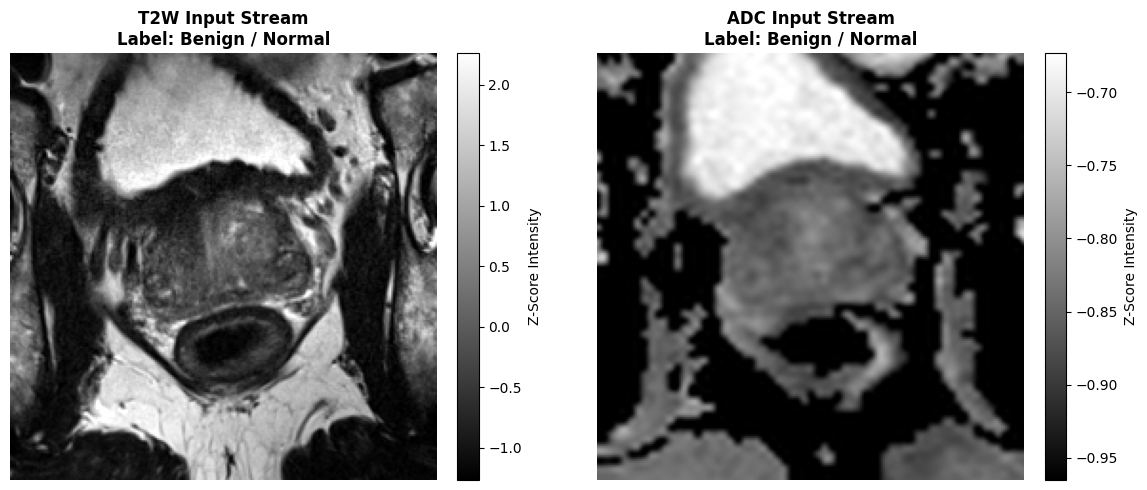

In [73]:
import matplotlib.pyplot as plt
import torch

# 1. Grab a single batch from your active training loader
t2w_batch, adc_batch, label_batch = next(iter(train_loader))

# 2. Pick a sample index inside the batch to inspect (0 to 15)
sample_idx = 0

# 3. Extract the 2D arrays and remove the channel dimension using .squeeze()
# Converted to numpy arrays for matplotlib
t2w_vis = t2w_batch[sample_idx].squeeze().numpy()
adc_vis = adc_batch[sample_idx].squeeze().numpy()
label = int(label_batch[sample_idx].item())

# 4. Set up the side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
status = "Malignant (CSPCa)" if label == 1 else "Benign / Normal"

# Plot T2W (Structural Anatomy Stream)
im1 = axes[0].imshow(t2w_vis, cmap='gray')
axes[0].set_title(f"T2W Input Stream\nLabel: {status}", fontsize=12, fontweight='bold')
axes[0].axis('off')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04).set_label('Z-Score Intensity')

# Plot ADC (Cellular Density Stream)
im2 = axes[1].imshow(adc_vis, cmap='gray') # medical standard is gray, 'bone', or 'inferno' for functional maps
axes[1].set_title(f"ADC Input Stream\nLabel: {status}", fontsize=12, fontweight='bold')
axes[1].axis('off')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04).set_label('Z-Score Intensity')

plt.tight_layout()
plt.show()

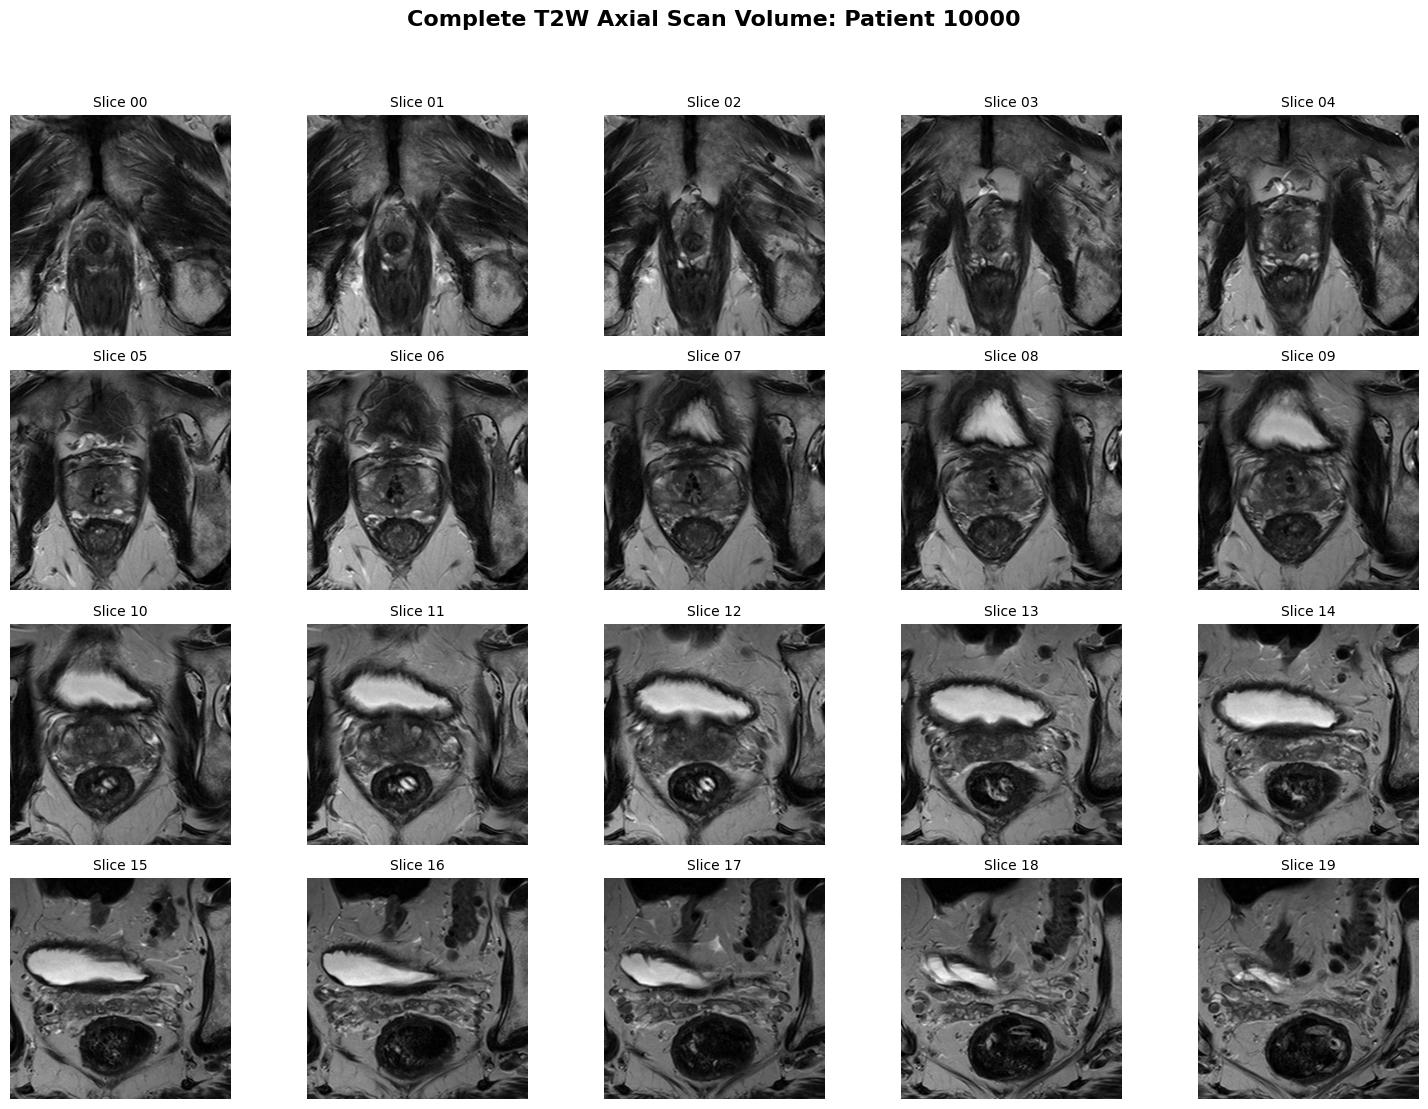

In [72]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. Set path to a specific patient file
patient_id = "10000"  # Replace with a real patient ID string
npz_path = f"/content/drive/MyDrive/PICAI/preprocessed/{patient_id}.npz"

if not os.path.exists(npz_path):
    print(f"File not found at {npz_path}. Check your patient ID!")
else:
    data = np.load(npz_path)
    t2w_volume = data['t2w']  # Shape should be (20, H, W)

    # 2. Set up a 4x5 grid for the 20 slices
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    axes = axes.flatten()  # Turn 2D grid into a 1D list for easy looping

    fig.suptitle(f"Complete T2W Axial Scan Volume: Patient {patient_id}",
                 fontsize=16, fontweight='bold', y=0.95)

    for slice_idx in range(20):
        # Display the slice
        axes[slice_idx].imshow(t2w_volume[slice_idx], cmap='gray')
        axes[slice_idx].set_title(f"Slice {slice_idx:02d}", fontsize=10)
        axes[slice_idx].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.92])
    plt.show()